# Initialize

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pickle as pk
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam 

2026-03-19 11:41:56.386914: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 11:41:56.449612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 11:41:58.034406: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Load data

EMNIST data is available in the form of a csv file. Each row contains pixel values of an image and the corresponding label. The first column contains the label and the rest of the columns contain pixel values. The pixel values are in the range of 0 to 255. The images are of size 28x28.

In [2]:
# Load dataset
# -------------------------------
# Your code here
x_train = pd.read_csv('ITDS252 Lab/emnist-balanced-train.csv')
x_test = pd.read_csv('ITDS252 Lab/emnist-balanced-test.csv')
# -------------------------------


# Show the first 5 rows of the training dataset
# -------------------------------
x_train.head()
# Your code here
# -------------------------------

,45,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.524,0.525,0.526,0.527,0.528,0.529,0.530,0.531,0.532,0.533
0,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,42,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Split the dataset into x_train, y_train, x_test, y_test
# -------------------------------
# Your code here
# แยกคอลัมน์แรก (index 0) เป็น y และคอลัมน์ที่เหลือ (index 1 เป็นต้นไป) เป็น x
# พร้อมกับเติม .values เพื่อแปลงจากตาราง Pandas ให้กลายเป็น NumPy array
y_train = x_train.iloc[:, 0].values
x_train = x_train.iloc[:, 1:].values

y_test = x_test.iloc[:, 0].values
x_test = x_test.iloc[:, 1:].values
# -------------------------------

# Show dataset statistic
print('Training size: ', len(x_train), 'samples')
print('Testing size: ', len(x_test), 'samples')
print('Image shape: ',  x_train[0].shape)
print('Label : ', sorted(np.unique(y_train)))

Training size:  112799 samples
Testing size:  18799 samples
Image shape:  (784,)
Label :  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]


In [4]:
# Show Sample data from training dataset
print(x_train[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   2   4   4   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   2  22  82 114 114  50  21   3   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0   0   0
   3  67 170 232 245 245 220 170  79   8   0   0   

## Data Pre-processing

In [5]:
# Pre-Process dataset
print('Data Shape:', x_train.shape)

# Reshape the dataset to 28x28 (1 row to 2D image)
# -------------------------------
# Your code here
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)
# -------------------------------

# Show Processed result
print('Data Shape:', x_train.shape)

Data Shape: (112799, 784)
Data Shape: (112799, 28, 28)


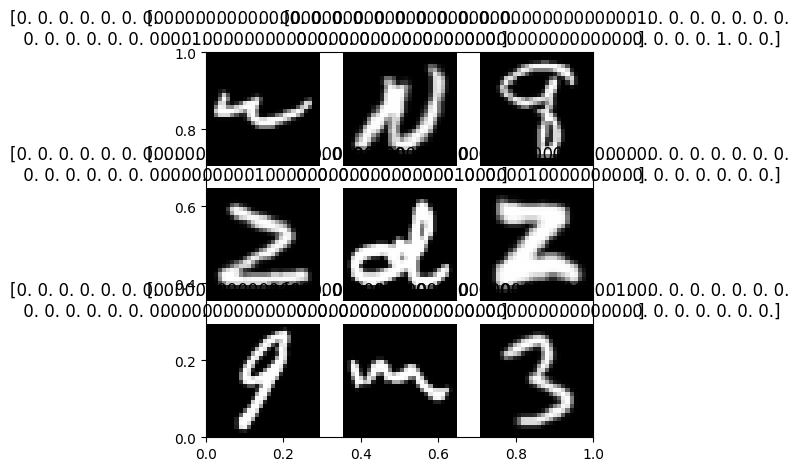

In [33]:
# Visualize sample dataset
inx =  np.random.randint(len(x_train), size=9)

plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(y_train[inx[i]])
    plt.axis('off')
plt.show()

It look like the data is wrong represented. We need to rotate the image 90 degrees and flip it horizontally to get the correct image.

In [7]:
# Image modify Function
# Note. cv2 is a library for image processing
import cv2
def image_processing(in_data):
    image = cv2.flip(in_data, 1)
    image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return image

In [8]:
# Modify images 
x_train = np.array([image_processing(x) for x in x_train])
x_test = np.array([image_processing(x) for x in x_test])

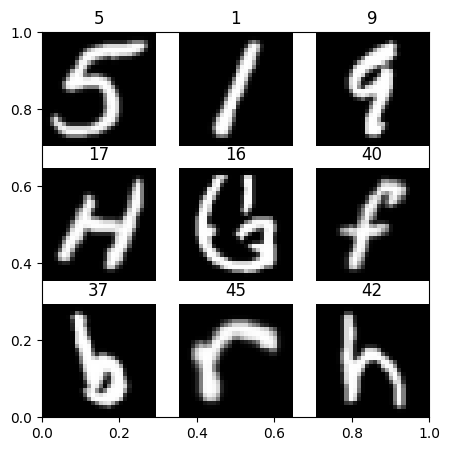

In [9]:
# Visualize sample dataset again
plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(y_train[inx[i]])
    plt.axis('off')
plt.show()

It still look like the label is worng. We need to decode the label to get the correct label.

In [10]:
# Modify label for visualization
# -------------------------------
# Your code here
emnist_classes = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
    'U', 'V', 'W', 'X', 'Y', 'Z',
    'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
]
# -------------------------------

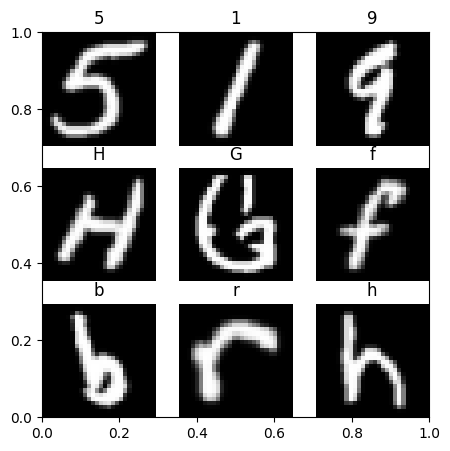

In [11]:
# Visualize sample dataset again
plt.subplots(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[inx[i]], cmap='gray')
    plt.title(emnist_classes[y_train[inx[i]]])
    plt.axis('off')
plt.show()

It look good now.

In [12]:
# Show sample image value/shape range
print('Train Max: ', max(np.unique(x_train)))
print('Train Min: ', min(np.unique(x_train)))
print('Test Max: ', max(np.unique(x_test)))
print('Test Min: ', min(np.unique(x_test)))
print('Train Shape: ', x_train.shape)
print('Test Shape: ', x_test.shape)

Train Max:  255
Train Min:  0
Test Max:  255
Test Min:  0
Train Shape:  (112799, 28, 28)
Test Shape:  (18799, 28, 28)


We need to normalize the pixel values to be in the range of 0 to 1.

In [13]:
# Normalize dataset to 0-1 from 0-255
# -------------------------------
# Your code here
# SAVE RAM
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# -------------------------------

# Show sample image value range
print('Train Max: ', max(np.unique(x_train)))
print('Train Min: ', min(np.unique(x_train)))
print('Test Max: ', max(np.unique(x_test)))
print('Test Min: ', min(np.unique(x_test)))

Train Max:  1.0
Train Min:  0.0
Test Max:  1.0
Test Min:  0.0


For the CNN, we need to reshape the data to be in the shape of (28, 28, 1).

In [14]:
# Reshape data to (W,H,C)
# -------------------------------
# Your code here
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
# -------------------------------

# Show sample image shape
print('Train Shape: ', x_train.shape)
print('Test Shape: ', x_test.shape)

Train Shape:  (112799, 28, 28, 1)
Test Shape:  (18799, 28, 28, 1)


Next, we need to encode the labels to be in the one-hot encoding format.

In [15]:
# convert class vectors to binary class matrices
num_classes = 47 # Your code here
print('Classes: ', num_classes)

# Convert label to one-hot encoding
# -------------------------------
# Your code here
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
# -------------------------------

# Show sample label
print(y_train[inx[:3]])

Classes:  47
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


# Create Model
Let's create a simple CNN model with 2 convolutional layers and 2 dense layers.

In [16]:
# Find the input shape
input_shape = x_train.shape[1:]

# Create CNN model
# The model is a simple CNN with 2 Conv2D layers and 2 MaxPooling2D layers
# The filters are 32 and 64 for the first and second Conv2D layers respectively
# The output layer is a Dense layer with softmax activation function
# After each Conv2D layer, a ReLU activation function is added
# After the second Conv2D layer, a Flatten layer is added to convert the 2D output to 1D
# A dropout layer is added at the end to prevent overfitting with a dropout rate of 0.5
cnn = keras.Sequential(
    [
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape, name='conv2D_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Mpool_1'),
        
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2D_2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Mpool_2'),
        
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name='conv1D'),
    ]
)


/home/suggus/miniconda3/envs/deep_learning/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773895373.799872   11325 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


The created model should have the following architecture:
```python
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
=================================================================
 conv2D_1 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 Mpool_1 (MaxPooling2D)      (None, 13, 13, 32)        0         
                                                                 
 conv2D_2 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 Mpool_2 (MaxPooling2D)      (None, 5, 5, 64)          0         
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dropout_1 (Dropout)         (None, 1600)              0         
                                                                 
 conv1D (Dense)              (None, 47)                75247     
                                                                 
=================================================================
Total params: 94,063
Trainable params: 94,063
Non-trainable params: 0
_________________________________________________________________
```

In [17]:
# Visualize Model
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2D_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Mpool_1 (MaxPooling2D)          │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2D_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Mpool_2 (MaxPooling2D)          │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D (Dense)                  │ (None, 47)             │        75,247 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,063 (367.43 KB)

 Trainable params: 94,063 (367.43 KB)

 Non-trainable params: 0 (0.00 B)

# Set Training Hyper-parameters
We will use the following hyper-parameters for training the model:
- Batch size: 512
- Number of epochs: 50
- Learning rate: 0.001
- Optimizer: Adam
- Loss function: Categorical Crossentropy
- Metrics: Accuracy

In [18]:
# Compile the model
batch_size = 512 # Your code here
epochs = 50 # Your code here
cnn.compile(
    loss='categorical_crossentropy',      
    optimizer=Adam(learning_rate=0.001),  
    metrics=['accuracy']
)

### Check the hardware environment
If we are using a GPU, the training will be faster.
The result of checking the hardware environment is somthing like this:
```python
Num GPUs Available: 1
GPU Name: /physical_device:GPU:0
```

In [19]:
# Check GPU is available or not
gpu_num = len(tf.config.list_physical_devices('GPU'))
print('Num GPUs Available: ', gpu_num)
if gpu_num > 0:
  gpu_name = tf.config.list_physical_devices('GPU')[0].name
  print('GPU Name: ', gpu_name)

Num GPUs Available:  1
GPU Name:  /physical_device:GPU:0


# Train
Let's train the model using the training data and validate it using the validation data.

In [20]:
# Train the model
# -------------------------------
# Your code here
history = cnn.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))
# -------------------------------

Epoch 1/50


2026-03-19 11:43:07.000682: I external/local_xla/xla/service/service.cc:163] XLA service 0x73c4ac004ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-19 11:43:07.000711: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-19 11:43:07.018772: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-19 11:43:07.119871: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-19 11:43:07.183610: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-19 11:43:08.

 18/221 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0576 - loss: 3.7716 

I0000 00:00:1773895391.114947   11689 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


216/221 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4063 - loss: 2.2658

2026-03-19 11:43:13.274125: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-19 11:43:14.263998: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_606', 204 bytes spill stores, 204 bytes spill loads

2026-03-19 11:43:14.296988: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_723', 440 bytes spill stores, 448 bytes spill loads

2026-03-19 11:43:14.317147: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_723', 44 b

221/221 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5879 - loss: 1.4785 - val_accuracy: 0.7832 - val_loss: 0.7198
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7774 - loss: 0.7112 - val_accuracy: 0.8254 - val_loss: 0.5617
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8093 - loss: 0.5976 - val_accuracy: 0.8395 - val_loss: 0.5068
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8239 - loss: 0.5424 - val_accuracy: 0.8502 - val_loss: 0.4748
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8340 - loss: 0.5073 - val_accuracy: 0.8495 - val_loss: 0.4573
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8402 - loss: 0.4832 - val_accuracy: 0.8576 - val_loss: 0.4396
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8466 - loss: 0.4620 - val_accuracy: 0.8618 - val_loss: 0.4223
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8503 - loss: 0.4478 - val_accuracy: 0.86

# Model Evaluation

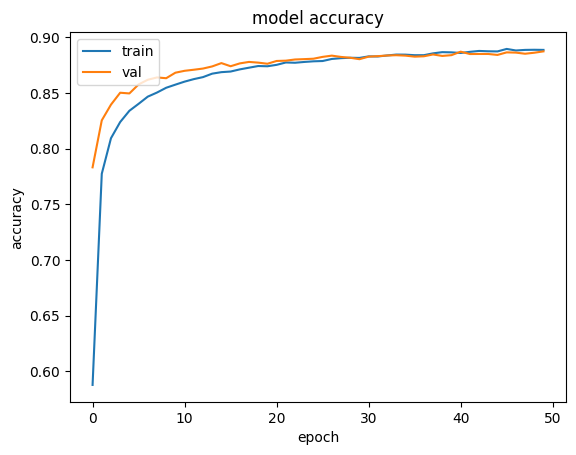

In [21]:
# Plot accuracy
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

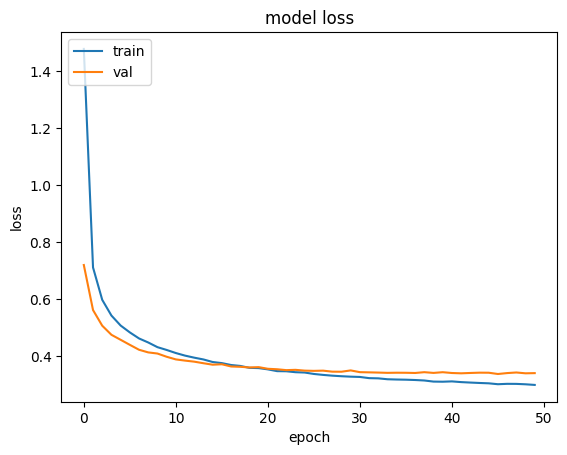

In [22]:
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [23]:
# Evaluate the model on the test data using `evaluate`
# -------------------------------
# Your code here
score = cnn.evaluate(x_test, y_test)
# -------------------------------

print("Test loss:", np.round(score[0], 4))
print("Test accuracy:", np.round(score[1], 4))

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8873 - loss: 0.3403
Test loss: 0.3403
Test accuracy: 0.8873


# Save Model

In [24]:
# Save the model
# -------------------------------
# Your code hereป
cnn.save('my_model.h5')
# -------------------------------

---
---
---

# Use model

When we want to use the model, we need to load the model and use it to predict the label of the input image.
<br>We don't need to train the model again.!!!

In [25]:
# Load the model
# Use keras.models.load_model() to load the model
# -------------------------------
# Your code here
from tensorflow import keras # เผื่อเซลล์นี้ไม่ได้ import ไว้
loaded_model = keras.models.load_model('my_model.h5')
# -------------------------------

In [26]:
# Predict the test data as a probability
# -------------------------------
# Your code here
y_pred = loaded_model.predict(x_test)
# -------------------------------

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
# Show output probability
print(y_pred[0])

[1.5693469e-07 1.3958968e-18 1.0223546e-08 3.6422643e-10 5.6355007e-12
 2.6659948e-09 3.8246524e-11 8.4150956e-17 6.8900493e-07 2.1710017e-08
 1.5965007e-11 1.5100117e-06 4.5948957e-05 1.0369637e-16 3.5569645e-03
 2.1587568e-06 1.0274533e-03 9.2435587e-15 7.3465678e-10 4.5662445e-14
 6.7989538e-09 7.7414096e-11 1.1321659e-19 8.9327470e-16 3.3925447e-09
 2.0706835e-08 8.3316348e-07 3.5410005e-06 2.3160864e-07 2.2227052e-16
 1.5229844e-19 5.0840353e-18 4.7474654e-21 4.8742477e-15 1.3773291e-13
 2.2414893e-08 1.6406511e-05 2.6681859e-10 1.4542051e-10 9.9501568e-01
 2.6767266e-06 2.6806892e-04 7.1980339e-13 2.4541064e-15 5.7538280e-05
 2.1556428e-09 1.1189526e-07]


In [28]:
# Decode the output probability to class
# Use np.argmax() to find the class with the highest probability
# -------------------------------
# Your code here
# 1. ใช้ argmax ดึง Index คลาสที่โมเดลให้ความน่าจะเป็นสูงสุด (ได้ผลลัพธ์เป็นเลข 0-46)
y_pred_class = np.argmax(y_pred, axis=1)

# 2. ดึงคลาสที่ถูกต้อง (เฉลย) ออกมาจาก y_test ด้วย
y_true_class = np.argmax(y_test, axis=1) 

# 3. แปลงเลข 0-46 ให้กลับกลายเป็นตัวอักษร โดยดึงจาก List emnist_classes ที่เราเคยสร้างไว้
y_pred_class_label = [emnist_classes[i] for i in y_pred_class]
y_test_label = [emnist_classes[i] for i in y_true_class]
# -------------------------------


# Show output class
print(y_pred_class[0], y_pred_class_label[0])

39 e


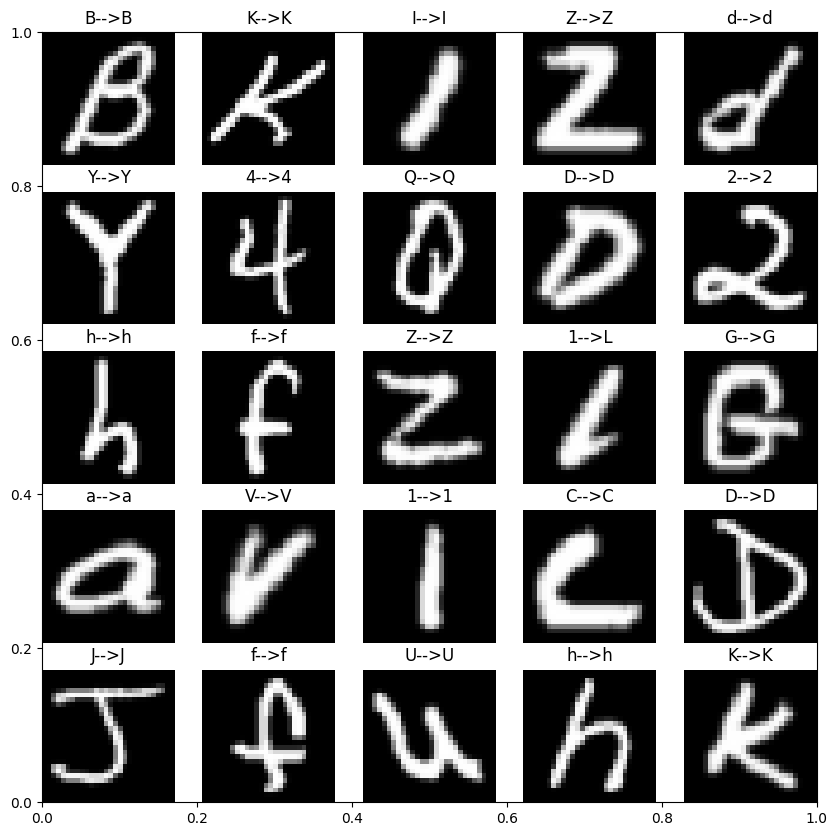

In [29]:
# Visualize sample dataset
inx =  np.random.randint(len(x_test), size=25)


plt.subplots(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[inx[i]], cmap='gray')
    plt.title(str(y_test_label[inx[i]])+'-->'+str(y_pred_class_label[inx[i]]))
    plt.axis('off')
plt.show()

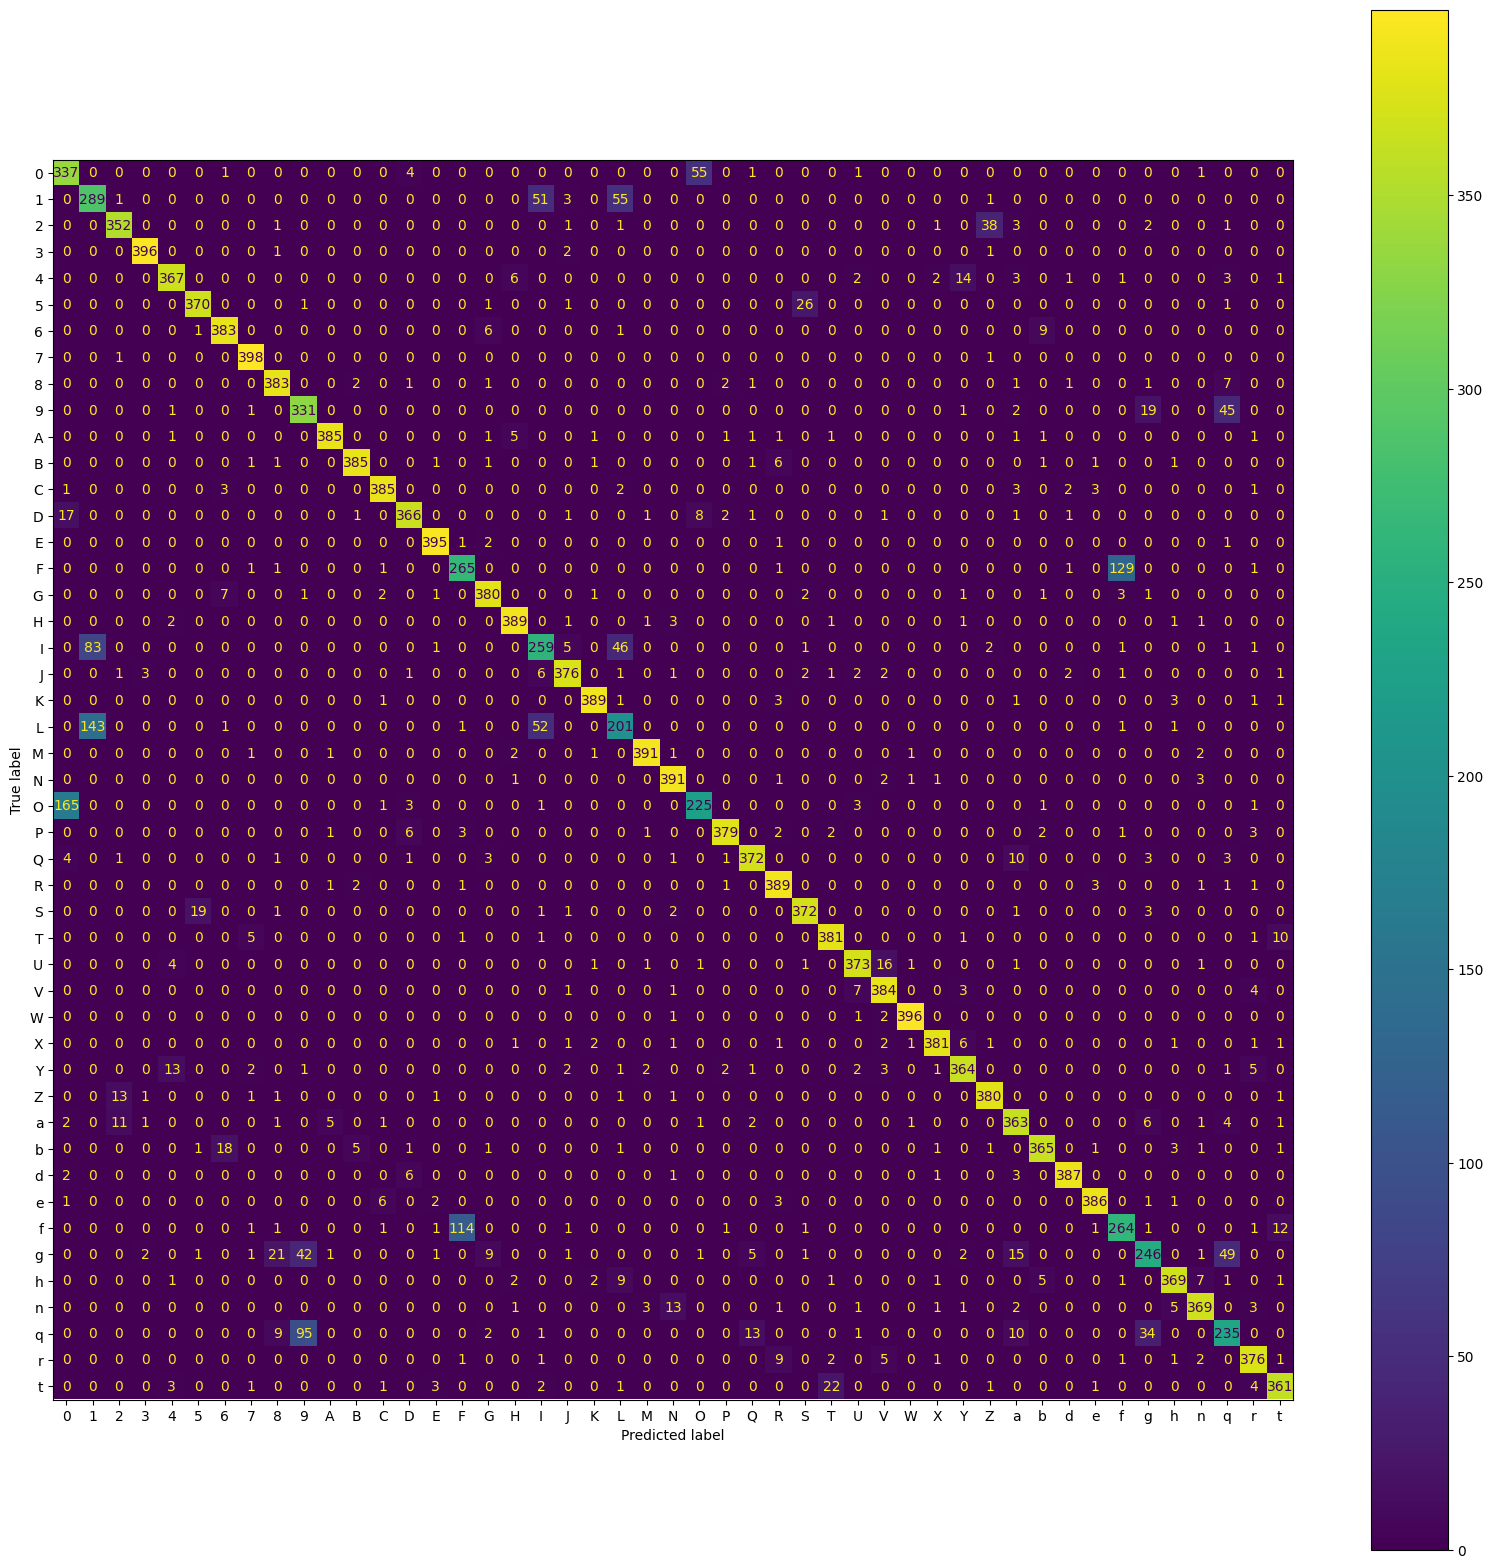

In [30]:
# Plot confusion matrix

# -------------------------------
# Your code here
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. คำนวณค่า Confusion Matrix โดยเทียบเฉลย (y_true_class) กับสิ่งที่ทาย (y_pred_class)
cm = confusion_matrix(y_true_class, y_pred_class)

# 2. ตั้งค่าขนาดรูปให้ใหญ่หน่อย เพราะเรามีตั้ง 47 คลาส ถ้าเล็กไปเดี๋ยวตัวเลขทับกันอ่านไม่ออก
fig, ax = plt.subplots(figsize=(20, 20))

# 3. สั่งวาดกราฟ พร้อมกับใส่แกนเป็นชื่อตัวอักษรของเรา
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emnist_classes)
disp.plot(ax=ax, cmap='viridis') # cmap='viridis' จะได้โทนสีม่วง-เหลือง เหมือนในรูปโจทย์เป๊ะๆ

plt.show()
# -------------------------------